# Clustering without dimensionality reduction on sampled data using different sampling methods

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap
import plotly.graph_objs as go
from collections import defaultdict

In [3]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [4]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

## Method 9 - min bins, polar stereo, geo and depth bins, 20 year separation

In [7]:
#min bins
flag = True

In [5]:
# Sample bins of bins (geographical and depth bins) in projection space
def sample_bins_of_bins_proj(df, n_x_bins=100, n_y_bins=100, n_depth_bins=5, projection='npstere', min_flag=True):
    # Define minimum latitude for projection
    lat_min = df['Latitude_[deg_N]'].min()

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')(lon_vals, lat_vals)

    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    # xy bins in projection space
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # depth bins in original depth space
    depth_bins = np.linspace(df['Depth_[m]'].min(), df['Depth_[m]'].max(), n_depth_bins + 1)

    # Assign each point to a bin
    df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
    df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)  
    df['depth_bin'] = pd.cut(df['Depth_[m]'], bins=depth_bins, labels=False, include_lowest=True)
    
    # Find bin with least data points and sample that many points from each bin
    if min_flag:
        min_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().min()
        sampled_df = df.groupby(['x_bin', 'y_bin', 'depth_bin']).apply(lambda x: x.sample(min_count, random_state=22)).reset_index(drop=True)
    else:
        avg_count = df.groupby(['x_bin', 'y_bin', 'depth_bin']).size().mean().round().astype(int)
        sampled_df = (df.groupby(['x_bin', 'y_bin', 'depth_bin'], group_keys=False).apply(lambda g: g.sample(n=min(len(g), avg_count), random_state=22)).reset_index(drop=True))
    return sampled_df

In [8]:
df_sampled_0 = sample_bins_of_bins_proj(df_80_00, projection='npstere', min_flag=flag)
df_sampled_1 = sample_bins_of_bins_proj(df_00_23, projection='npstere', min_flag=flag)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['x_bin'] = pd.cut(x_vals, bins=x_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y_bin'] = pd.cut(y_vals, bins=y_bins, labels=False, include_lowest=True)
/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:24: SettingWithCopyWa

In [9]:
def profileNo_vs_xy_bins(
    df: pd.DataFrame,
    n_x_bins: int = 100,
    n_y_bins: int = 100,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95,
    projection: str = 'npstere'
) -> None:
    """
    Plot the number of profiles in each bin using polar stereographic projection.
    Args:
        df (pd.DataFrame): The dataset to plot.
        n_x_bins (int): Number of bins in the x direction. Defaults to 100.
        n_y_bins (int): Number of bins in the y direction. Defaults to 100.
        show_threshold (bool, optional): Whether to show the threshold marker. Defaults to False.
        threshold_quantile (float, optional): The quantile value for threshold calculation. Defaults to 0.95.
        projection (str, optional): Basemap projection string. Defaults to 'npstere'.
    Returns:
        None
    """
    # Set up the polar stereographic projection
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution='l')

    # Reproject lat/lon to x/y (projection coordinates in metres)
    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges in projected space
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()
    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Digitize points into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of profiles per bin
    H = np.zeros((n_x_bins, n_y_bins), dtype=int)
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Flatten to get non-zero bin counts (matching original behaviour of only counting occupied bins)
    g_len = H[H > 0].flatten().tolist()
    g_len_sorted = sorted(g_len)

    # Threshold / transition point detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    # Build Plotly traces
    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

In [15]:
profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [14]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [16]:
import random
from sklearn.mixture import GaussianMixture

In [17]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [18]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [19]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

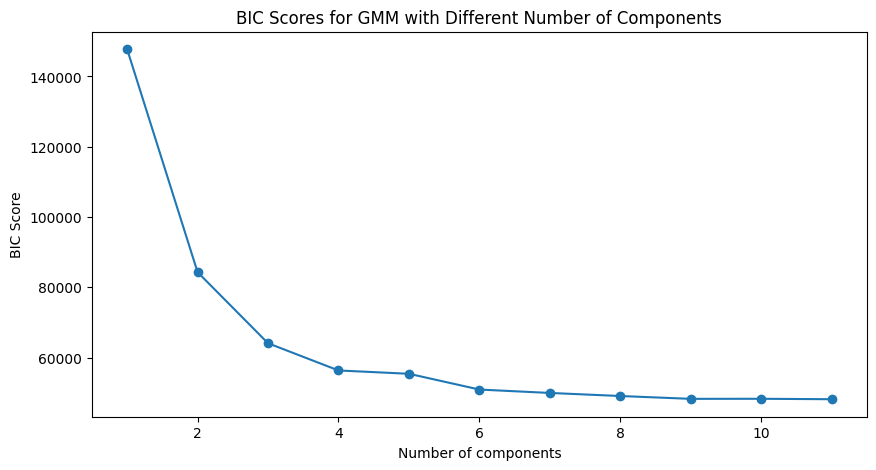

In [20]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [21]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [22]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [23]:
df_sampled['gmm_label'] = labels

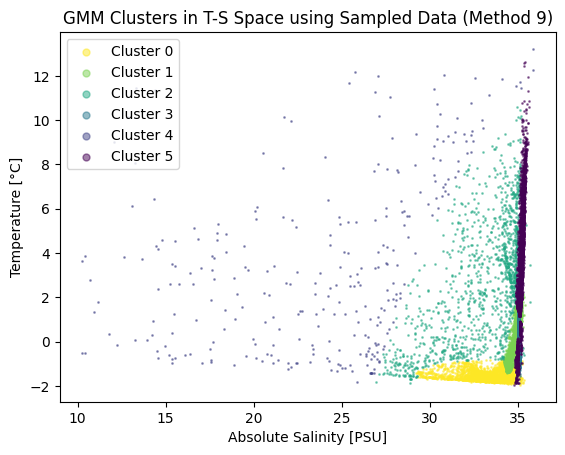

In [26]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [ ]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [ ]:
import random
from sklearn.mixture import GaussianMixture

In [ ]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [ ]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [ ]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

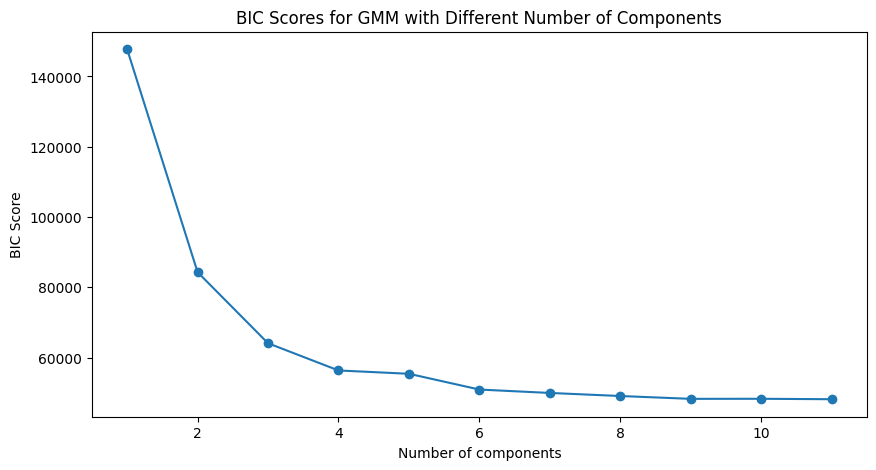

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [ ]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [ ]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [ ]:
df_sampled['gmm_label'] = labels

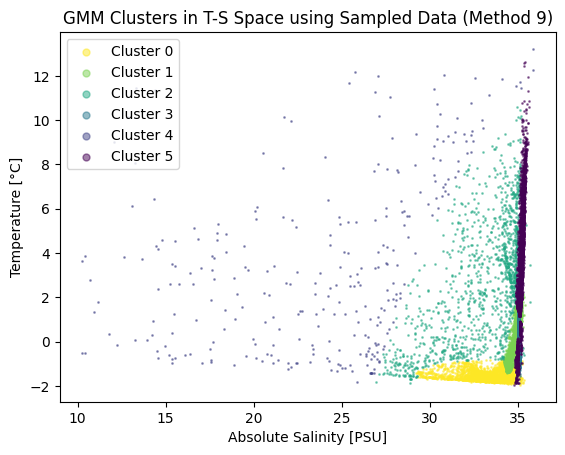

In [ ]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

# Method 21 - polar stereographic projection, geo and depth bins, 20 year separation, average bin cap

In [27]:
#avg bins
flag = False

In [28]:
df_sampled_0 = sample_bins_of_bins_proj(df_80_00, projection='npstere', min_flag=flag)
df_sampled_1 = sample_bins_of_bins_proj(df_00_23, projection='npstere', min_flag=flag)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_73872/3865529425.py:24: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [29]:
profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [30]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [31]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

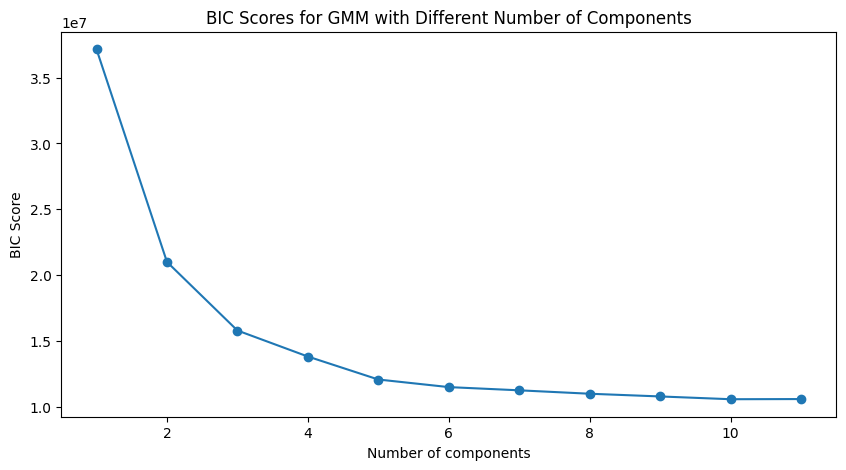

In [32]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [34]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 5

In [35]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [36]:
df_sampled['gmm_label'] = labels

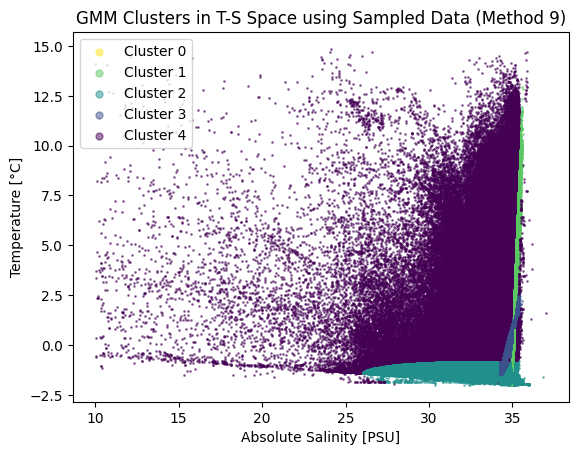

In [37]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 9)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

# Method 26 - lat-lon bins, 95th percentile cap random sampling

In [40]:
def profileNo_vs_latlon_bins(
    df: pd.DataFrame,
    lat_step: float,
    lon_step: float,
    show_threshold: bool = False,
    threshold_quantile: float = 0.95
) -> transition_point:
    
    # === Identical bin construction to sample_cap_bins / plot_heatmap_npts ===
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1
    # =========================================================================

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    # Count per bin
    from collections import defaultdict
    bin_counts = defaultdict(int)
    for i in range(len(lon_vals)):
        bin_counts[(lon_idx[i], lat_idx[i])] += 1

    g_len = list(bin_counts.values())
    g_len_sorted = sorted(g_len)

    # Threshold detection
    transition_point = None
    if len(g_len_sorted) > 1:
        g_len_diff = np.diff(g_len_sorted)
        threshold = np.quantile(g_len_diff, threshold_quantile)
        for i in range(1, len(g_len_sorted)):
            if g_len_sorted[i] - g_len_sorted[i - 1] > threshold:
                transition_point = i - 1
                break

    trace = go.Scatter(
        x=list(range(len(g_len_sorted))),
        y=g_len_sorted
    )

    if show_threshold and transition_point is not None:
        red_dot = go.Scatter(
            x=[transition_point],
            y=[g_len_sorted[transition_point]],
            mode='markers',
            marker=dict(color='red', size=10)
        )
        fig_data = [trace, red_dot]
    else:
        fig_data = [trace]

    layout = go.Layout(
        xaxis=dict(title='Bin No.'),
        yaxis=dict(title='Number of points per bin')
    )
    fig = go.Figure(data=fig_data, layout=layout)
    fig.show()

    return transition_point

In [41]:
profileNo_vs_latlon_bins(df_ST, lat_step=2, lon_step=2, show_threshold=True, threshold_quantile=0.95)

In [39]:
def sample_cap_bins(df, thresh, lon_step=5, lat_step=5):
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 55, 90

    lon_bins = np.arange(lon_min, lon_max + lon_step, lon_step)

    sin_step = np.sin(np.radians(lat_step)) - np.sin(np.radians(0))
    sin_min = np.sin(np.radians(lat_min))
    sin_max = np.sin(np.radians(lat_max))
    sin_bins = np.arange(sin_min, sin_max + sin_step, sin_step)
    lat_bins = np.degrees(np.arcsin(np.clip(sin_bins, -1, 1)))

    n_lon_bins = len(lon_bins) - 1
    n_lat_bins = len(lat_bins) - 1

    lon_vals = df['Longitude_[deg_E]'].values
    lat_vals = df['Latitude_[deg_N]'].values

    lon_idx = np.clip(np.digitize(lon_vals, lon_bins) - 1, 0, n_lon_bins - 1)
    lat_idx = np.clip(np.digitize(lat_vals, lat_bins) - 1, 0, n_lat_bins - 1)

    bin_members = defaultdict(list)
    for i in range(len(lon_vals)):
        bin_members[(lon_idx[i], lat_idx[i])].append(i)

    sampled_indices = []
    for (xi, yi), members in bin_members.items():
        if len(members) > thresh:
            sampled_indices.extend(
                np.random.choice(members, size=thresh, replace=False).tolist()
            )
        else:
            sampled_indices.extend(members)

    return df.iloc[sampled_indices].copy()

In [ ]:
df_sampled = sample_cap_bins(df_ST, thresh=465_000, lon_step=2, lat_step=2)